In [2]:
#pip install statsmodels

  Using cached patsy-1.0.2-py2.py3-none-any.whl.metadata (3.6 kB)
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.5 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.5 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.5 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.5 MB 409.2 kB/s eta 0:00:23
   -- ------------------------------------- 0.5/9.5 MB 409.2 kB/s eta 0:00:23
   --- ------------------------------------ 0.8/9.5 MB 455.0 kB/s eta 0:00:20
   --- ------------------------------------ 0.8/9.5 MB 455.0 kB/s eta 0:00:20
   --- ------------------------------------ 0.8/9.5 MB 455.0 kB/s eta 0:00:20
   --- ------------------------------------ 0.8/9.5 MB 455.0 kB/s eta 0:00:20
   --- ------------------------------------ 0.8/9.5 

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols

In [4]:
df = pd.read_csv("Extended_Employee_Performance_and_Productivity_Data.csv", parse_dates=["Hire_Date"])
df.head()

,Employee_ID,Department,Gender,Age,Job_Title,Hire_Date,Years_At_Company,Education_Level,Performance_Score,Monthly_Salary,Work_Hours_Per_Week,Projects_Handled,Overtime_Hours,Sick_Days,Remote_Work_Frequency,Team_Size,Training_Hours,Promotions,Employee_Satisfaction_Score,Resigned
0,1,IT,Male,55,Specialist,2022-01-19 08:03:05.556036,2,High School,5,6750.0,33,32,22,2,0,14,66,0,2.63,False
1,2,Finance,Male,29,Developer,2024-04-18 08:03:05.556036,0,High School,5,7500.0,34,34,13,14,100,12,61,2,1.72,False
2,3,Finance,Male,55,Specialist,2015-10-26 08:03:05.556036,8,High School,3,5850.0,37,27,6,3,50,10,1,0,3.17,False
3,4,Customer Support,Female,48,Analyst,2016-10-22 08:03:05.556036,7,Bachelor,2,4800.0,52,10,28,12,100,10,0,1,1.86,False
4,5,Engineering,Female,36,Analyst,2021-07-23 08:03:05.556036,3,Bachelor,2,4800.0,38,11,29,13,100,15,9,1,1.25,False


In [5]:
df["Satisfaction_Level"] = pd.cut(
    df["Employee_Satisfaction_Score"],
    bins=[0, 2, 3, 5],
    labels=["Low", "Medium", "High"]
)

## Résultat du test du Khi-deux

Le test du Khi-deux montre qu’il existe une relation statistiquement significative entre le département et le niveau de satisfaction des employés (p-value = 0.0196 < 0.05). Cela signifie que la satisfaction des employés dépend du département auquel ils appartiennent. En termes métier, certains départements semblent offrir de meilleures conditions de travail ou un environnement plus favorable que d’autres, ce qui influence directement le niveau de satisfaction des employés.

In [6]:
contingency_table = pd.crosstab(df["Department"], df["Satisfaction_Level"])

chi2, p, dof, expected = stats.chi2_contingency(contingency_table)

print("Chi2:", chi2)
print("p-value:", p)

Chi2: 29.693758328221016
p-value: 0.019656534285258036


## Force de l'association (V de Cramer)

Le V de Cramer obtenu est de 0.012, ce qui indique une association très faible entre le département et le niveau de satisfaction des employés. Bien que le test du Khi-deux ait révélé une relation statistiquement significative, la force de cette relation reste négligeable. En pratique, cela signifie que le département influence très peu la satisfaction des employés, et que d’autres facteurs doivent probablement jouer un rôle plus important.

In [7]:
n = contingency_table.sum().sum()
phi2 = chi2 / n
r, k = contingency_table.shape
cramer_v = np.sqrt(phi2 / (min(k-1, r-1)))

print("Cramer's V:", cramer_v)

Cramer's V: 0.012184777045194758


## Test de normalité (Shapiro-Wilk)

Le test de Shapiro-Wilk a été appliqué pour vérifier si les scores de performance suivent une distribution normale dans chaque département. Les p-values obtenues sont extrêmement faibles (toutes largement inférieures à 0.05), ce qui indique que l’hypothèse de normalité est rejetée pour tous les départements. 

Ainsi, les scores de performance ne suivent pas une distribution normale. Par conséquent, il est plus approprié d’utiliser des tests non paramétriques, comme le test de Kruskal-Wallis, pour comparer les performances entre départements.

In [8]:
for dept in df["Department"].unique():
    stat, p = stats.shapiro(df[df["Department"] == dept]["Performance_Score"])
    print(dept, "p-value:", p)

IT p-value: 3.970711475836997e-67
Finance p-value: 6.589045493730032e-67
Customer Support p-value: 8.459658600365414e-67
Engineering p-value: 1.566790379080312e-66
Marketing p-value: 1.1898479414690454e-66
HR p-value: 1.8847774906274815e-66
Operations p-value: 7.340315292678987e-67
Sales p-value: 1.257753148761355e-66
Legal p-value: 3.7073422551376584e-67


C:\Users\PC\miniconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 11131.
  res = hypotest_fun_out(*samples, **kwds)
C:\Users\PC\miniconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 11200.
  res = hypotest_fun_out(*samples, **kwds)
C:\Users\PC\miniconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 11116.
  res = hypotest_fun_out(*samples, **kwds)
C:\Users\PC\miniconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 10956.
  res = hypotest_fun_out(*samples, **kwds)
C:\Users\PC\miniconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: UserWarning: s

## Test d'homogénéité des variances (Levene)

Le test de Levene a été réalisé afin de vérifier si les variances des scores de performance sont homogènes entre les différents départements. La p-value obtenue est de 0.394, supérieure au seuil de 5 % (0.05), ce qui signifie que l’hypothèse d’égalité des variances ne peut pas être rejetée.

Ainsi, les variances des scores de performance peuvent être considérées comme homogènes entre les départements. Cependant, étant donné que les données ne suivent pas une distribution normale, il est préférable d’utiliser un test non paramétrique comme le test de Kruskal-Wallis pour comparer les performances entre départements.

In [9]:
groups = [df[df["Department"] == d]["Performance_Score"] for d in df["Department"].unique()]
stat, p = stats.levene(*groups)

print("Levene p-value:", p)

Levene p-value: 0.39404796436097433


## Résultat de l’ANOVA : Performance selon le département

L’analyse de variance (ANOVA) a été réalisée afin de comparer les scores de performance entre les différents départements. Le résultat montre une p-value de 0.467, supérieure au seuil de 5 % (0.05), ce qui indique que les différences observées ne sont pas statistiquement significatives.

Ainsi, il n’existe pas de différence significative des scores de performance entre les départements. En termes métier, cela signifie que le département n’a pas d’influence notable sur la performance des employés.

In [10]:
model = ols('Performance_Score ~ C(Department)', data=df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)

print(anova_table)

                     sum_sq       df         F    PR(>F)
C(Department)      15.33215      8.0  0.957562  0.467323
Residual       200127.57936  99991.0       NaN       NaN


## Résultat du test de Kruskal-Wallis

Le test de Kruskal-Wallis a été réalisé afin de comparer les scores de performance entre les différents départements sans supposer de normalité des données. La p-value obtenue est de 0.468, supérieure au seuil de 5 % (0.05), ce qui indique que les différences observées ne sont pas statistiquement significatives.

Ainsi, il n’existe pas de différence significative des scores de performance entre les départements. En termes métier, cela signifie que le département n’a pas d’influence notable sur la performance des employés.

In [11]:
stat, p = stats.kruskal(*groups)
print("Kruskal p-value:", p)

Kruskal p-value: 0.46758244279890715


## Corrélation de Pearson : Heures de travail et performance

Le test de corrélation de Pearson a été réalisé afin d’évaluer la relation entre le nombre d’heures de travail par semaine et le score de performance des employés. Le coefficient de corrélation obtenu est de -0.006, avec une p-value de 0.075, supérieure au seuil de 5 % (0.05).

Ces résultats indiquent qu’il n’existe pas de relation linéaire significative entre les heures de travail et la performance. En termes métier, cela signifie que travailler davantage d’heures ne conduit pas nécessairement à une meilleure performance des employés.

In [12]:
corr, p = stats.pearsonr(df["Work_Hours_Per_Week"], df["Performance_Score"])
print("Pearson:", corr, "p-value:", p)

Pearson: -0.005627251855261635 p-value: 0.0751602612027619


## Corrélation de Spearman : Heures supplémentaires et satisfaction

Le test de corrélation de Spearman montre un coefficient de corrélation très proche de zéro (0.001), ce qui indique l’absence de relation monotone entre les heures supplémentaires et le niveau de satisfaction des employés. En pratique, le nombre d’heures supplémentaires effectuées ne semble pas influencer significativement la satisfaction des employés.

In [13]:
corr, p = stats.spearmanr(df["Overtime_Hours"], df["Employee_Satisfaction_Score"])
print("Spearman:", corr)

Spearman: 0.0010421301414357178


## Analyse visuelle : Performance par département

Le boxplot montre que les distributions des scores de performance sont très similaires entre les différents départements. Les médianes sont proches et les intervalles interquartiles se chevauchent fortement, ce qui indique une absence de différences notables entre les groupes.

Cette observation visuelle confirme les résultats des tests statistiques (ANOVA et Kruskal-Wallis), qui n’ont pas mis en évidence de différences significatives de performance entre les départements. En termes métier, cela suggère que la performance des employés est globalement homogène, quel que soit le département.

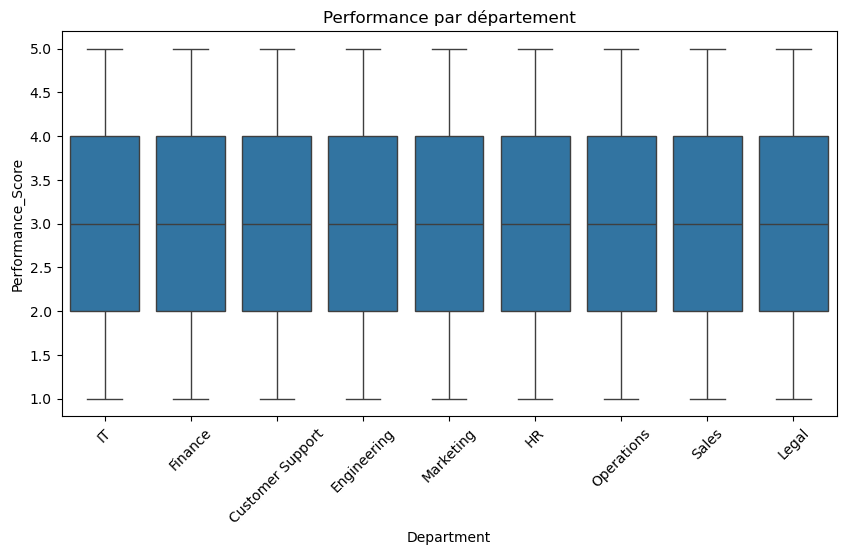

In [14]:
plt.figure(figsize=(10,5))
sns.boxplot(x="Department", y="Performance_Score", data=df)
plt.xticks(rotation=45)
plt.title("Performance par département")
plt.show()

## Analyse des corrélations entre variables

La matrice de corrélation montre que la majorité des variables présentent des corrélations très faibles, proches de zéro, indiquant l’absence de relations linéaires significatives entre elles. La seule relation notable observée concerne le score de performance et le salaire mensuel, avec une corrélation positive modérée (0.51), suggérant que les employés plus performants ont tendance à percevoir un salaire plus élevé.

En revanche, les autres variables, telles que les heures de travail, les heures supplémentaires ou le nombre de projets, ne semblent pas avoir d’influence significative sur la performance ou la satisfaction. Cela indique que la performance des employés dépend probablement d’autres facteurs non mesurés dans ce jeu de données.

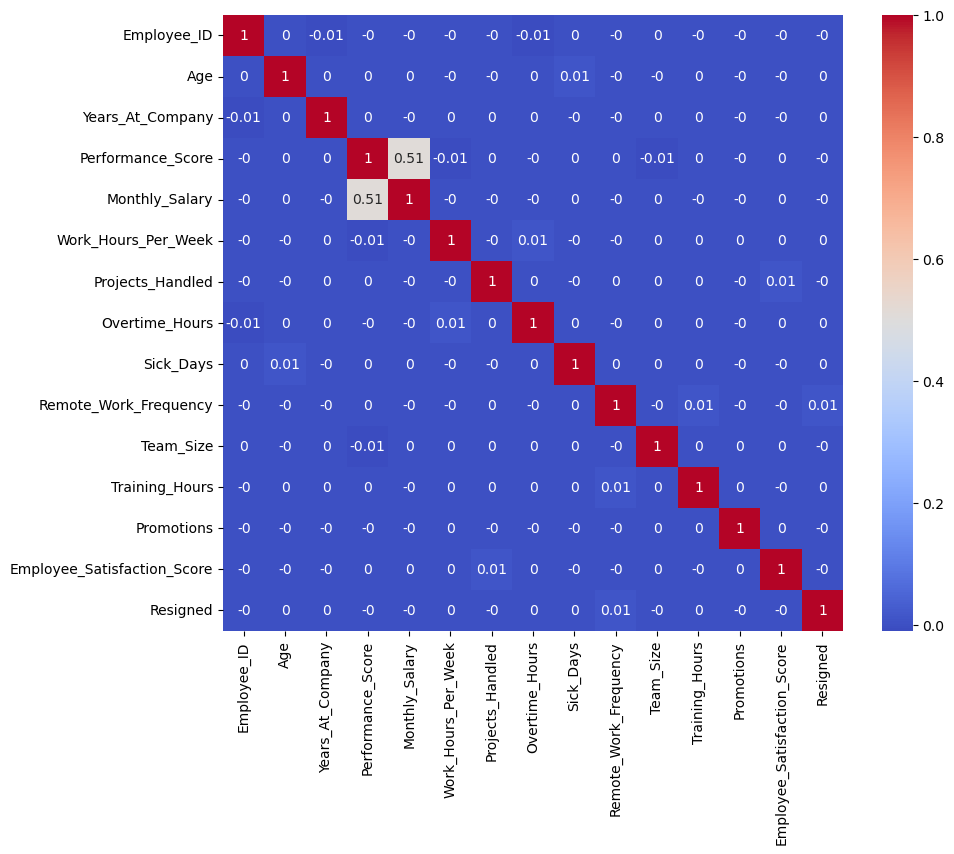

In [17]:
corr = df.corr(numeric_only=True).round(2)

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

## Analyse visuelle : Heures de travail et performance

Le scatter plot montre une dispersion uniforme des points, sans tendance apparente entre le nombre d’heures de travail hebdomadaires et le score de performance. Les niveaux de performance restent constants quel que soit le nombre d’heures travaillées.

Cette observation visuelle confirme les résultats du test de corrélation de Pearson, qui n’a révélé aucune relation significative entre ces deux variables. En termes métier, cela suggère que travailler davantage d’heures n’améliore pas la performance des employés.

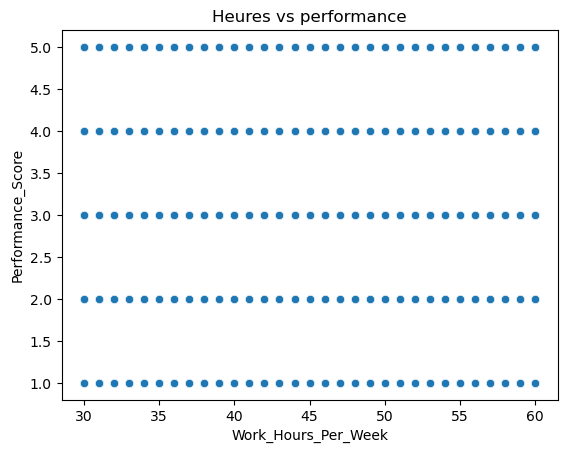

In [16]:
sns.scatterplot(x="Work_Hours_Per_Week", y="Performance_Score", data=df)
plt.title("Heures vs performance")
plt.show()